**#### Data Cleaning**

In [1]:
import pandas as pd
import numpy as np


In [5]:
df = pd.read_csv('C:/Users/arifi/OneDrive/Documents/_Belajar-DA/dataset/pharma-data.csv')

In [11]:
df.shape

(254082, 18)

In [7]:
df.head()

,Distributor,Customer Name,City,Country,Latitude,Longitude,Channel,Sub-channel,Product Name,Product Class,Quantity,Price,Sales,Month,Year,Name of Sales Rep,Manager,Sales Team
0,Gottlieb-Cruickshank,"Zieme, Doyle and Kunze",Lublin,Poland,51.2333,22.5667,Hospital,Private,Topipizole,Mood Stabilizers,4.0,368,1472.0,January,2018,Mary Gerrard,Britanny Bold,Delta
1,Gottlieb-Cruickshank,Feest PLC,Świecie,Poland,53.4167,18.4333,Pharmacy,Retail,Choriotrisin,Antibiotics,7.0,591,4137.0,January,2018,Jessica Smith,Britanny Bold,Delta
2,Gottlieb-Cruickshank,Medhurst-Beer Pharmaceutical Limited,Rybnik,Poland,50.0833,18.5000,Pharmacy,Institution,Acantaine,Antibiotics,30.0,66,1980.0,January,2018,Steve Pepple,Tracy Banks,Bravo
3,Gottlieb-Cruickshank,Barton Ltd Pharma Plc,Czeladź,Poland,50.3333,19.0833,Hospital,Private,Lioletine Refliruvax,Analgesics,6.0,435,2610.0,January,2018,Mary Gerrard,Britanny Bold,Delta
4,Gottlieb-Cruickshank,Keeling LLC Pharmacy,Olsztyn,Poland,53.7800,20.4942,Pharmacy,Retail,Oxymotroban Fexoformin,Analgesics,20.0,458,9160.0,January,2018,Anne Wu,Britanny Bold,Delta


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 254082 entries, 0 to 254081
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Distributor        254082 non-null  object 
 1   Customer Name      254082 non-null  object 
 2   City               254082 non-null  object 
 3   Country            254082 non-null  object 
 4   Latitude           254082 non-null  float64
 5   Longitude          254082 non-null  float64
 6   Channel            254082 non-null  object 
 7   Sub-channel        254082 non-null  object 
 8   Product Name       254082 non-null  object 
 9   Product Class      254082 non-null  object 
 10  Quantity           254082 non-null  float64
 11  Price              254082 non-null  int64  
 12  Sales              254082 non-null  float64
 13  Month              254082 non-null  object 
 14  Year               254082 non-null  int64  
 15  Name of Sales Rep  254082 non-null  object 
 16  Ma

In [21]:
df.nunique()

Distributor             29
Customer Name          751
City                   749
Country                  2
Latitude               655
Longitude              709
Channel                  2
Sub-channel              4
Product Name           240
Product Class            6
Quantity              1735
Price                  210
Sales                20546
Month                   12
Year                     4
Name of Sales Rep       13
Manager                  4
Sales Team               4
dtype: int64

In [22]:
df.isnull().sum().sort_values(ascending=False)

Distributor          0
Customer Name        0
Manager              0
Name of Sales Rep    0
Year                 0
Month                0
Sales                0
Price                0
Quantity             0
Product Class        0
Product Name         0
Sub-channel          0
Channel              0
Longitude            0
Latitude             0
Country              0
City                 0
Sales Team           0
dtype: int64

In [51]:
df.duplicated().sum()

4

In [50]:
duplicates = df[df.duplicated()]
duplicates

,Distributor,Customer Name,City,Country,Latitude,Longitude,Channel,Sub-channel,Product Name,Product Class,Quantity,Price,Sales,Month,Year,Name of Sales Rep,Manager,Sales Team
24328,Prohaska-Kuhic,"Steuber, Skiles and Kilback Pharma Plc",Sosnowiec,Poland,50.3000,19.1667,Pharmacy,Retail,Dasagestin,Analgesics,10.0,386,3860.0,September,2018,Mary Gerrard,Britanny Bold,Delta
57178,Erdman,Fritsch LLC Pharmaceutical Ltd,Mülheim,Germany,51.4283,6.8789,Hospital,Government,Amphesirox,Antiseptics,30.0,25,750.0,April,2017,Jessica Smith,Britanny Bold,Delta
140251,Gerlach LLC,Crona PLC Pharmaceutical Ltd,Schloß Holte-Stukenbrock,Germany,51.8833,8.6167,Pharmacy,Institution,Thionide,Analgesics,10.0,113,1130.0,October,2018,Erica Jones,James Goodwill,Alfa
177689,Gerlach LLC,"Steuber, Skiles and Kilback Pharmacy",Datteln,Germany,51.6539,7.3417,Pharmacy,Institution,Interfeferon Aspipex,Antiseptics,10.0,416,4160.0,June,2019,Alan Ray,James Goodwill,Alfa


In [52]:
df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist())

,Distributor,Customer Name,City,Country,Latitude,Longitude,Channel,Sub-channel,Product Name,Product Class,Quantity,Price,Sales,Month,Year,Name of Sales Rep,Manager,Sales Team
53977,Erdman,Fritsch LLC Pharmaceutical Ltd,Mülheim,Germany,51.4283,6.8789,Hospital,Government,Amphesirox,Antiseptics,30.0,25,750.0,April,2017,Jessica Smith,Britanny Bold,Delta
57178,Erdman,Fritsch LLC Pharmaceutical Ltd,Mülheim,Germany,51.4283,6.8789,Hospital,Government,Amphesirox,Antiseptics,30.0,25,750.0,April,2017,Jessica Smith,Britanny Bold,Delta
137363,Gerlach LLC,Crona PLC Pharmaceutical Ltd,Schloß Holte-Stukenbrock,Germany,51.8833,8.6167,Pharmacy,Institution,Thionide,Analgesics,10.0,113,1130.0,October,2018,Erica Jones,James Goodwill,Alfa
140251,Gerlach LLC,Crona PLC Pharmaceutical Ltd,Schloß Holte-Stukenbrock,Germany,51.8833,8.6167,Pharmacy,Institution,Thionide,Analgesics,10.0,113,1130.0,October,2018,Erica Jones,James Goodwill,Alfa
173838,Gerlach LLC,"Steuber, Skiles and Kilback Pharmacy",Datteln,Germany,51.6539,7.3417,Pharmacy,Institution,Interfeferon Aspipex,Antiseptics,10.0,416,4160.0,June,2019,Alan Ray,James Goodwill,Alfa
177689,Gerlach LLC,"Steuber, Skiles and Kilback Pharmacy",Datteln,Germany,51.6539,7.3417,Pharmacy,Institution,Interfeferon Aspipex,Antiseptics,10.0,416,4160.0,June,2019,Alan Ray,James Goodwill,Alfa
13821,Prohaska-Kuhic,"Steuber, Skiles and Kilback Pharma Plc",Sosnowiec,Poland,50.3000,19.1667,Pharmacy,Retail,Dasagestin,Analgesics,10.0,386,3860.0,September,2018,Mary Gerrard,Britanny Bold,Delta
24328,Prohaska-Kuhic,"Steuber, Skiles and Kilback Pharma Plc",Sosnowiec,Poland,50.3000,19.1667,Pharmacy,Retail,Dasagestin,Analgesics,10.0,386,3860.0,September,2018,Mary Gerrard,Britanny Bold,Delta


In [54]:
df = df.drop_duplicates()

In [55]:
df.duplicated().sum()

0

In [56]:
# df['Product Name'].nunique()
df['Product Name'].value_counts()

Product Name
Diprotaine               1143
Nevanide Actozide        1137
Solasteride              1136
Acantaine                1133
Menogine                 1132
                         ... 
Adrecetam Barazoxane     1000
Vibratosine Alemtrace    1000
Immurenol Temarate        999
Secrelazine Insonamic     994
Adideine                  986
Name: count, Length: 240, dtype: int64

In [57]:
# df['Customer Name'].nunique()
df['Customer Name'].value_counts()

Customer Name
Spinka, Schowalter and Conn                   440
Fritsch, Hodkiewicz and Sipes Pharma Plc      437
Weber Ltd Pharmaceutical Ltd                  436
Corkery-Kovacek Pharm                         436
Nolan, DuBuque and Schultz                    434
                                             ... 
Fadel-West                                    172
Wiegand, Jast and Yost Pharma Plc             164
Bernier, Murphy and Rau Pharmaceutical Ltd    164
Schaefer-Rolfson                              162
Medhurst-Beer Pharmaceutical Limited          157
Name: count, Length: 751, dtype: int64

In [58]:
df['Month'].min(), df['Month'].max()

('April', 'September')

In [136]:
month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

df['Month'] = pd.Categorical(
    df['Month'],
    categories=month_order,
    ordered=True
)

In [144]:
df['Month'].min(), df['Month'].max()

('January', 'December')

In [59]:
df['Year'].min(), df['Year'].max()

(2017, 2020)

In [146]:
df = df.sort_values(by=['Year', 'Month'], ascending=[True, True])
df['Month_Year'] = df['Month'].astype(str) + '-' + df['Year'].astype(str)
print(df['Month_Year'].unique())

['January-2017' 'February-2017' 'March-2017' 'April-2017' 'May-2017'
 'June-2017' 'July-2017' 'August-2017' 'September-2017' 'October-2017'
 'November-2017' 'December-2017' 'January-2018' 'February-2018'
 'March-2018' 'April-2018' 'May-2018' 'June-2018' 'July-2018'
 'August-2018' 'September-2018' 'October-2018' 'November-2018'
 'December-2018' 'January-2019' 'February-2019' 'March-2019' 'April-2019'
 'May-2019' 'June-2019' 'July-2019' 'August-2019' 'September-2019'
 'October-2019' 'November-2019' 'December-2019' 'January-2020'
 'February-2020' 'March-2020' 'April-2020' 'May-2020' 'June-2020'
 'July-2020' 'August-2020' 'September-2020' 'October-2020' 'November-2020'
 'December-2020']


In [60]:
df.shape

(254078, 18)

#### **Exploratory Data Analysis All Years**

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

In [147]:
print(f"Jumlah transaksi : {len(df):,}")
print(f"Jumlah distributor : {df['Distributor'].nunique()}")
print(f"Jumlah customer : {df['Customer Name'].nunique()}")
print(f"Jumlah produk : {df['Product Name'].nunique()}")
print(f"Jumlah kategori produk : {df['Product Class'].nunique()}")
print(f"Jumlah kota : {df['City'].nunique()}")
print(f"Jumlah sales rep : {df['Name of Sales Rep'].nunique()}")
print(f"Jumlah manager : {df['Manager'].nunique()}")
print(f"Kota : {df['City'].nunique()}")

Jumlah transaksi : 254,078
Jumlah distributor : 29
Jumlah customer : 751
Jumlah produk : 240
Jumlah kategori produk : 6
Jumlah kota : 749
Jumlah sales rep : 13
Jumlah manager : 4
Kota : 749


In [ ]:
# Total Sales dan Total Quantity (2017–2020)

total_sales = df['Sales'].sum() / 1e9
total_quantity = df['Quantity'].sum()

print(f"Total Sales (2017-2020)    : {total_sales:.2f} Billion")
print(f"Total Quantity (2017-2020) : {total_quantity:,.0f}")

Total Sales (2017–2020)    : 11.80 Billion
Total Quantity (2017–2020) : 28,678,719


In [154]:
aov_million = df['Sales'].mean() / 1e3

print(f"Average Order Value (AOV): {aov_million:.2f} K")

Average Order Value (AOV): 46.44 K


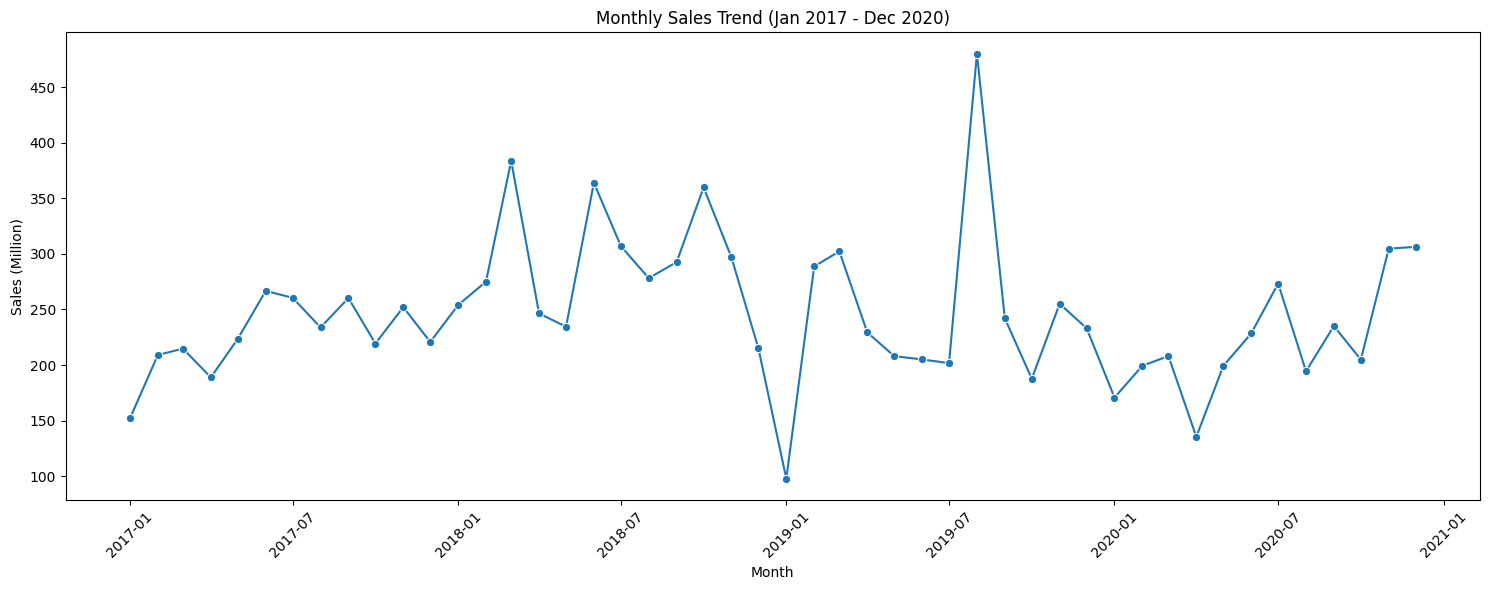

In [158]:
df['Month'] = pd.Categorical(
    df['Month'],
    categories=month_order,
    ordered=True
)

# Membuat kolom tanggal (awal bulan)
df['Date'] = pd.to_datetime(
    df['Year'].astype(str) + '-' + df['Month'].astype(str),
    format='%Y-%B'
)

# Agregasi total sales per bulan
monthly_sales = (
    df.groupby('Date')['Sales']
      .sum()
      .reset_index()
)

# Konversi ke Million
monthly_sales['Sales'] = monthly_sales['Sales'] / 1e6

# Visualisasi
plt.figure(figsize=(15,6))

sns.lineplot(
    data=monthly_sales,
    x='Date',
    y='Sales',
    marker='o'
)

plt.title('Monthly Sales Trend (Jan 2017 - Dec 2020)')
plt.xlabel('Month')
plt.ylabel('Sales (Million)')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [174]:
pareto_class = (
    df.groupby('Product Class')['Sales']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

# Konversi Sales ke Billion
pareto_class['Sales (Billion)'] = (
    pareto_class['Sales'] / 1e9
).round(2)

# Persentase kontribusi (dibulatkan)
pareto_class['Sales (%)'] = (
    pareto_class['Sales'] /
    pareto_class['Sales'].sum() * 100
).round(0).astype(int)


pareto_class = pareto_class.drop(columns='Sales')
pareto_class

,Product Class,Sales (Billion),Sales (%)
0,Analgesics,2.37,20
1,Antiseptics,2.24,19
2,Mood Stabilizers,2.06,17
3,Antipiretics,1.88,16
4,Antibiotics,1.75,15
5,Antimalarial,1.50,13


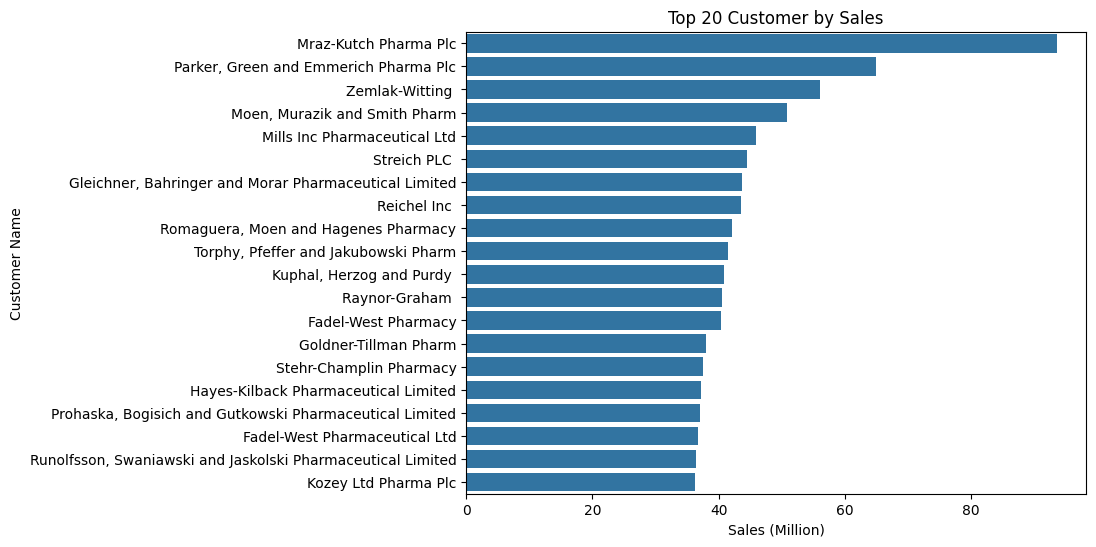

In [179]:
top20_customer = customer_sales.head(20)

plt.figure(figsize=(8,6))

sns.barplot(
    data=top20_customer,
    x=top20_customer['Sales']/1e6,
    y='Customer Name'
)

plt.xlabel('Sales (Million)')
plt.title('Top 20 Customer by Sales')

plt.show()

In [181]:
city_sales = (
    df.groupby('City')['Sales']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

# Konversi ke Million
city_sales['Sales (Million)'] = (
    city_sales['Sales'] / 1e6
).round(2)

city_sales = city_sales.drop(columns='Sales')

city_sales.head(10)

,City,Sales (Million)
0,Butzbach,93.56
1,Baesweiler,64.89
2,Cuxhaven,56.01
3,Friedberg,52.18
4,Altenburg,50.89
5,Emsdetten,45.94
6,Bottrop,44.45
7,Freising,43.78
8,Trier,43.50
9,Castrop-Rauxel,42.07


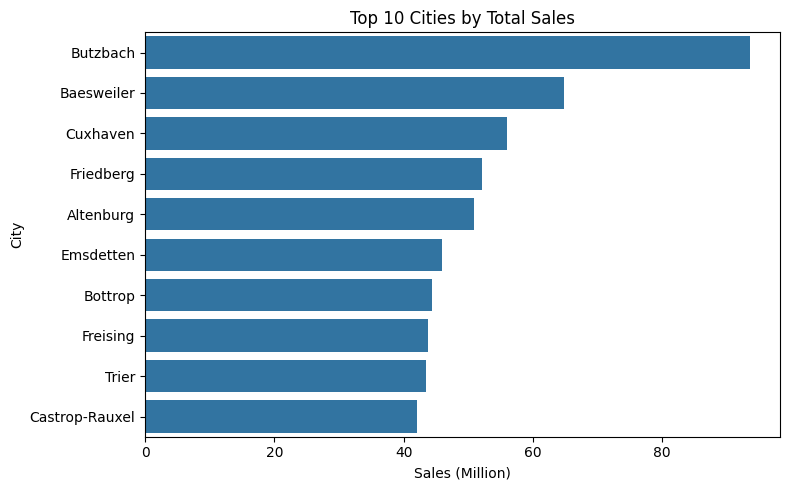

In [182]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=city_sales.head(10),
    x='Sales (Million)',
    y='City'
)

plt.title('Top 10 Cities by Total Sales')
plt.xlabel('Sales (Million)')
plt.ylabel('City')

plt.tight_layout()
plt.show()

In [184]:
channel_sales = (
    df.groupby('Channel')['Sales']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

channel_sales['Sales (Billion)'] = (
    channel_sales['Sales'] / 1e9
).round(2)

channel_sales['Sales (%)'] = (
    channel_sales['Sales'] /
    channel_sales['Sales'].sum() * 100
).round(0).astype(int)

channel_sales = channel_sales.drop(columns='Sales')

channel_sales

,Channel,Sales (Billion),Sales (%)
0,Pharmacy,6.22,53
1,Hospital,5.58,47


In [185]:
subchannel_sales = (
    df.groupby('Sub-channel')['Sales']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

subchannel_sales['Sales (Billion)'] = (
    subchannel_sales['Sales'] / 1e9
).round(2)

subchannel_sales['Sales (%)'] = (
    subchannel_sales['Sales'] /
    subchannel_sales['Sales'].sum() * 100
).round(0).astype(int)

subchannel_sales = subchannel_sales.drop(columns='Sales')

subchannel_sales

,Sub-channel,Sales (Billion),Sales (%)
0,Retail,3.34,28
1,Government,3.06,26
2,Institution,2.88,24
3,Private,2.52,21


<Axes: xlabel='Price', ylabel='Quantity'>

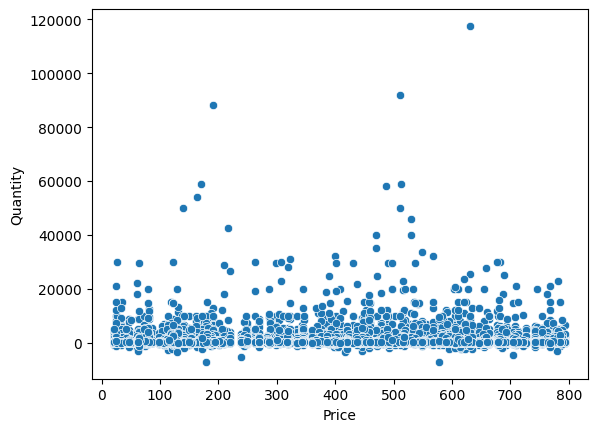

In [126]:
sns.scatterplot(
    data=df,
    x='Price',
    y='Quantity'
)

#### **Year-over-Year (YoY) & Deep-Dive per Tahun (2017, 2018, 2019, 2020)**

**###### 2017 (Baseline Year)**

In [186]:
df2017 = df[df['Year'] == 2017].copy()

print(f"Jumlah transaksi tahun 2017: {len(df2017):,}")

Jumlah transaksi tahun 2017: 56,485


In [187]:
top_product_2017 = (
    df2017.groupby('Product Name')['Sales']
          .sum()
          .sort_values(ascending=False)
          .reset_index()
)

top_product_2017['Sales (Million)'] = (
    top_product_2017['Sales'] / 1e6
).round(2)

top_product_2017 = top_product_2017.drop(columns='Sales')

top_product_2017.head(10)

,Product Name,Sales (Million)
0,Magnemunex,36.23
1,Ketastadil,34.78
2,Docstryl Rivacin,34.37
3,Morphizolid Tianalin,29.82
4,Betanem,28.97
5,Trazobalamin,27.37
6,Liomulin,26.36
7,Cephozumab Synmethate,26.24
8,Decidenu Galantrigine,26.04
9,Diprolimus,25.92


In [190]:
sales_rep_2017 = (
    df2017.groupby('Name of Sales Rep')['Sales']
          .sum()
          .sort_values(ascending=False)
          .reset_index()
)

sales_rep_2017['Sales (Million)'] = (
    sales_rep_2017['Sales'] / 1e6
).round(2)

sales_rep_2017 = sales_rep_2017.drop(columns='Sales')

sales_rep_2017

,Name of Sales Rep,Sales (Million)
0,Anne Wu,240.17
1,Mary Gerrard,236.79
2,Abigail Thompson,227.12
3,Morris Garcia,222.50
4,Jessica Smith,217.53
5,Alan Ray,216.99
6,Thompson Crawford,211.50
7,Erica Jones,203.54
8,Sheila Stones,199.51
9,Jimmy Grey,189.61


In [192]:
monthly_sales_2017 = (
    df2017.groupby('Month', observed=False)['Sales']
          .sum()
          .reindex(month_order)
          .reset_index()
)

monthly_sales_2017['Sales (Million)'] = (
    monthly_sales_2017['Sales'] / 1e6
).round(2)

average_monthly_sales = monthly_sales_2017['Sales (Million)'].mean()

print(f"Average Monthly Sales 2017: {average_monthly_sales:.2f} Million")

monthly_sales_2017 = monthly_sales_2017.drop(columns='Sales')
monthly_sales_2017

Average Monthly Sales 2017: 225.12 Million


,Month,Sales (Million)
0,January,151.87
1,February,209.00
2,March,214.77
3,April,188.80
4,May,223.63
5,June,266.67
6,July,260.49
7,August,233.83
8,September,260.25
9,October,219.34


**###### 2018 & 2019**

In [230]:
# Total Sales per Tahun
sales_yoy = (
    df[df['Year'].isin([2017, 2018, 2019, 2020])]
    .groupby('Year')['Sales']
    .sum()
    .reset_index()
)

# Konversi ke Billion
sales_yoy['Sales (Billion)'] = (
    sales_yoy['Sales'] / 1e9
).round(2)

# Hitung YoY Growth
sales_yoy['YoY Growth (%)'] = (
    sales_yoy['Sales']
    .pct_change() * 100
).round(2)

sales_yoy.drop(columns='Sales')

,Year,Sales (Billion),YoY Growth (%)
0,2017,2.70,NaN
1,2018,3.51,29.81
2,2019,2.93,-16.42
3,2020,2.66,-9.26


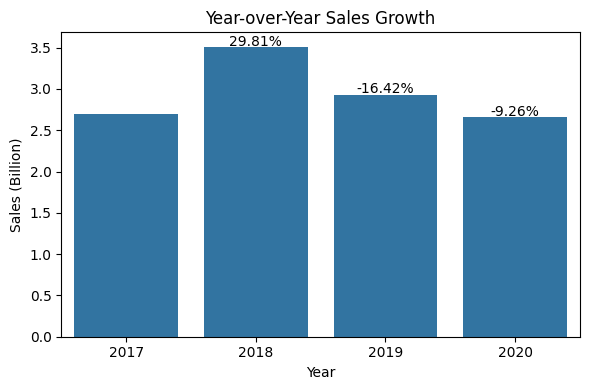

In [231]:
plt.figure(figsize=(6,4))

ax = sns.barplot(
    data=sales_yoy,
    x='Year',
    y='Sales (Billion)'
)

# Tambahkan label YoY
for i, row in sales_yoy.iterrows():
    if pd.notnull(row['YoY Growth (%)']):
        ax.text(
            i,
            row['Sales (Billion)'] + 0.015,
            f"{row['YoY Growth (%)']}%",
            ha='center'
        )

plt.title('Year-over-Year Sales Growth')
plt.xlabel('Year')
plt.ylabel('Sales (Billion)')

plt.tight_layout()
plt.show()

In [206]:
product_shift = (
    df[df['Year'].isin([2017, 2018, 2019])]
    .groupby(['Year','Product Class'])['Sales']
    .sum()
    .reset_index()
)

product_shift['Sales (Million)'] = (
    product_shift['Sales']/1e6
).round(2)

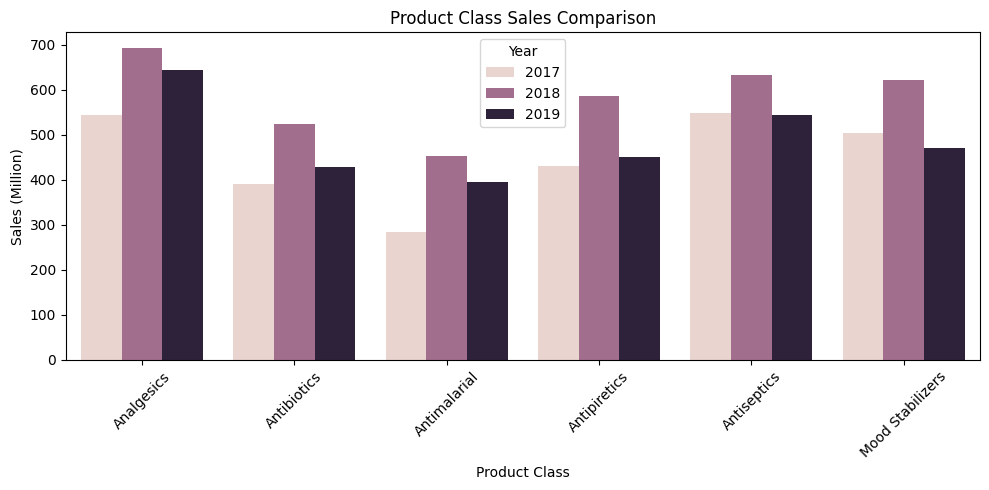

In [207]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=product_shift,
    x='Product Class',
    y='Sales (Million)',
    hue='Year'
)

plt.title('Product Class Sales Comparison')
plt.xlabel('Product Class')
plt.ylabel('Sales (Million)')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

###### **Tahun 2020**

In [221]:
product_2020 = (
    df.groupby(['Year', 'Product Class'])['Sales']
      .sum()
      .reset_index()
)

product_2020['Sales (Million)'] = (
    product_2020['Sales'] / 1e6
).round(2)

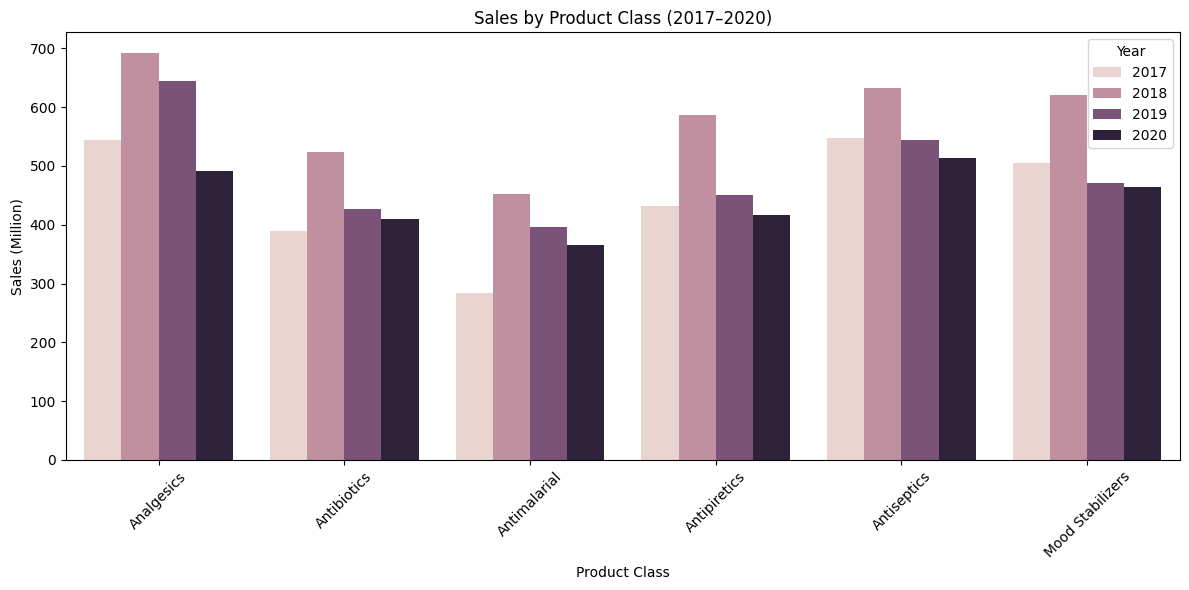

In [222]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=product_2020,
    x='Product Class',
    y='Sales (Million)',
    hue='Year'
)

plt.title('Sales by Product Class (2017–2020)')
plt.xlabel('Product Class')
plt.ylabel('Sales (Million)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [229]:
product_growth = (
    df[df['Year'].isin([2019, 2020])]
    .groupby(['Product Class', 'Year'])['Sales']
    .sum()
    .unstack()
)

# Konversi Sales ke Million
product_growth[2019] = (product_growth[2019] / 1e6).round(2)
product_growth[2020] = (product_growth[2020] / 1e6).round(2)

# Hitung Growth (%) menggunakan nilai asli
sales_original = (
    df[df['Year'].isin([2019, 2020])]
    .groupby(['Product Class', 'Year'])['Sales']
    .sum()
    .unstack()
)

product_growth['Growth (%)'] = (
    (sales_original[2020] - sales_original[2019])
    / sales_original[2019] * 100
).round(2)

product_growth = product_growth.sort_values(
    'Growth (%)',
    ascending=False
)

product_growth

Year,2019,2020,Growth (%)
Product Class,,,
Mood Stabilizers,470.53,463.78,-1.43
Antibiotics,427.29,409.55,-4.15
Antiseptics,543.44,513.54,-5.50
Antimalarial,395.26,365.79,-7.46
Antipiretics,450.18,415.94,-7.61
Analgesics,644.24,491.08,-23.77


In [225]:
channel_year = (
    df.groupby(['Year', 'Channel'])['Sales']
      .sum()
      .reset_index()
)

channel_year['Sales (Million)'] = (
    channel_year['Sales'] / 1e6
).round(2)

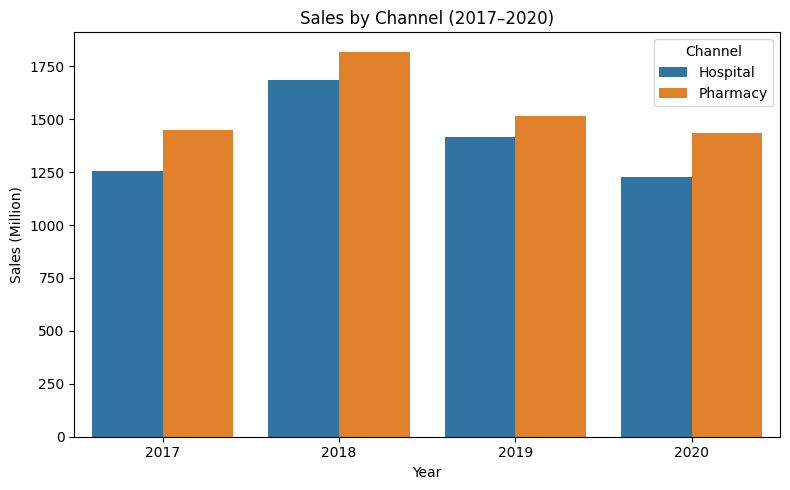

In [226]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=channel_year,
    x='Year',
    y='Sales (Million)',
    hue='Channel'
)

plt.title('Sales by Channel (2017–2020)')
plt.xlabel('Year')
plt.ylabel('Sales (Million)')

plt.tight_layout()
plt.show()

In [236]:
subchannel_sales = (
    df.groupby('Sub-channel')['Sales']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

# Konversi ke Billion
subchannel_sales['Sales (Billion)'] = (
    subchannel_sales['Sales'] / 1e9
).round(2)

# Persentase kontribusi
subchannel_sales['Sales (%)'] = (
    subchannel_sales['Sales'] /
    subchannel_sales['Sales'].sum() * 100
).round(0).astype(int)

subchannel_sales = subchannel_sales.drop(columns='Sales')

subchannel_sales

,Sub-channel,Sales (Billion),Sales (%)
0,Retail,3.34,28
1,Government,3.06,26
2,Institution,2.88,24
3,Private,2.52,21


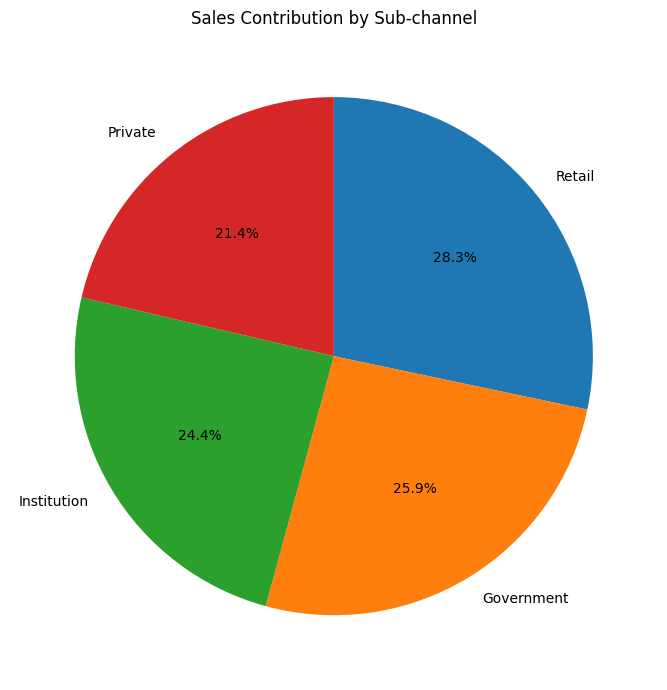

In [241]:
subchannel_sales = (
    df.groupby('Sub-channel')['Sales']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

# Konversi ke Billion
subchannel_sales['Sales (Billion)'] = (
    subchannel_sales['Sales'] / 1e9
).round(2)

plt.figure(figsize=(7,7))

plt.pie(
    subchannel_sales['Sales (Billion)'],
    labels=subchannel_sales['Sub-channel'],
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False
)

plt.title('Sales Contribution by Sub-channel')

plt.tight_layout()
plt.show()